In [1]:
# Description: Plot Figure 3 (Shelf edge sea level and cross-isobath geostrophic velocity).
# Author:      André Palóczy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from xarray import open_dataset
from gsw import f as fcor

In [3]:
def near2(x, y, x0, y0):
    dr2 = (x - x0)**2 + (y - y0)**2
    return int(np.nanargmin(dr2))

## Define file paths, read along-isobath WOA/EN4 climatologies and CMEMS ADT

In [4]:
head = "../proc/"
d = np.load(head + "isobath_200m.npz")
xi, yi, di = d["xi"], d["yi"], d["di"]
xseg0, yseg0 = np.loadtxt(head + "segment_latitudes_wei_etal2024.txt", unpack=True)
fseg = [near2(xi, yi, xseg0[i], yseg0[i]) for i in range(len(yseg0))]

# Clip start/end to fit segments.
xseg, yseg = xi[fseg], yi[fseg]
dibound = di[fseg]
txt_segs = ["AS", "CSS", "PSBS", "MS", "HS", "WSS", "NENSS"]

def annotate_segments(axi, dibound=dibound, txt_segs=txt_segs, ytxt=-190):
    for i in range(len(txt_segs)):
        xtxt = 0.5*(dibound[i] + dibound[i+1])
        axi.text(xtxt, ytxt, txt_segs[i], ha="center", va="center", fontsize=12, color="k", bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="k", lw=1))

In [5]:
rho0 = 1027.5 # [kg/m3]
g = 9.81 # [m/s2]

ssns = ["JFM", "AMJ", "JAS", "OND"]
fname_TSu = head + "alongisob_seasonal_EN4_200m.nc"
fname_TSu_woa = head + "alongisob_seasonal_WOA23_200m.nc"
fname_adt_ssnavg = head + "seasonal_altimetry_adt_200misob.nc"

dsadt = open_dataset(fname_adt_ssnavg)
dsTSu = open_dataset(fname_TSu)
dsTSu_woa = open_dataset(fname_TSu_woa)

getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


In [6]:
# Calculate surface geostrophic velocity from altimetry.
x = dsadt["x"].values
adt = dsadt["adt"]
adt_annual = adt.mean("season")
adt_std = adt.std("season")
adt_annual["x"] = adt_annual["x"]*1e3 # [m]

detady_annual = adt_annual.differentiate("x")
f0 = fcor(adt_annual["lat"].lat.mean())
ug0_annual = -g*detady_annual/f0 # [m/s]
adt["x"] = adt["x"]*1e3 # [m]
detady_ssn = adt.differentiate("x")
ug0_ssn = -g*detady_ssn/f0 # [m/s]
ug0_ssn_std = ug0_ssn.std("season")

ug0_annual = ug0_annual*1e2 # [cm/s]
ug0_ssn = ug0_ssn*1e2 # [cm/s]
ug0_ssn_std = ug0_ssn_std*1e2 # [cm/s]

In [7]:
# Calculate seasonal steric sea levels (EN4).
dz = -(dsTSu["z"].values[1] - dsTSu["z"].values[0])
rho = dsTSu["rho"] + 1000
rhop = rho - rho0
etas = -rhop.sum(dim="z")*dz/rho0
etas_annual = etas.mean("t")
etas_std = etas.std("t")

# Calculate seasonal steric sea levels (WOA).
dz = -(dsTSu_woa["z"].values[1] - dsTSu_woa["z"].values[0])
rho = dsTSu_woa["rho"] + 1000
rhop = rho - rho0
etas_woa = -rhop.sum(dim="z")*dz/rho0
etas_woa_annual = etas_woa.mean("t")
etas_woa_std = etas_woa.std("t")
etas_woa_annual["x"] = etas_woa_annual["x"]*1e3
detady_woa_annual = etas_woa_annual.differentiate("x")
ug0_woa_annual = -g*detady_woa_annual/f0 # [m/s]

## Calculate correlations between Absolute Dynamic Topography and steric sea level.

In [8]:
for i in range(5):
    if i<4:
        ssni = ssns[i]
        r = np.corrcoef(etas_woa.sel(t=ssni).values, etas.sel(t=ssni).values)[0][1]
    else:
        r = np.corrcoef(etas_woa_annual.values, etas_annual.values)[0][1]
        ssni = "Avg"

    print(ssni + ": WOA-EN4 r, r2 = %1.2f, %1.2f"%(r, r**2))

print("==============================================")
print("Correlations between steric eta (EN4) and ADT:")
print("")
for i in range(5):
    if i<4:
        ssni = ssns[i]
        r = np.corrcoef(adt.sel(season=ssni).values, etas.sel(t=ssni).values)[0][1]
    else:
        r = np.corrcoef(adt_annual, etas_annual.values)[0][1]
        ssni = "Avg"

    print(ssni + ": ADT-EN4 steric eta r, r2 = %1.2f, %1.2f"%(r, r**2))

print("================================================")
print("Correlations between steric eta (WOA23) and ADT:")
print("")
for i in range(5):
    if i<4:
        ssni = ssns[i]
        r = np.corrcoef(adt.sel(season=ssni).values, etas_woa.sel(t=ssni).values)[0][1]
    else:
        r = np.corrcoef(adt_annual, etas_woa_annual.values)[0][1]
        ssni = "Avg"

    print(ssni + ": ADT-WOA23 steric eta r, r2 = %1.2f, %1.2f"%(r, r**2))

JFM: WOA-EN4 r, r2 = 0.93, 0.86
AMJ: WOA-EN4 r, r2 = 0.95, 0.89
JAS: WOA-EN4 r, r2 = 0.90, 0.81
OND: WOA-EN4 r, r2 = 0.95, 0.90
Avg: WOA-EN4 r, r2 = 0.95, 0.91
Correlations between steric eta (EN4) and ADT:

JFM: ADT-EN4 steric eta r, r2 = 0.87, 0.76
AMJ: ADT-EN4 steric eta r, r2 = 0.94, 0.89
JAS: ADT-EN4 steric eta r, r2 = 0.85, 0.73
OND: ADT-EN4 steric eta r, r2 = 0.90, 0.82
Avg: ADT-EN4 steric eta r, r2 = 0.91, 0.83
Correlations between steric eta (WOA23) and ADT:

JFM: ADT-WOA23 steric eta r, r2 = 0.93, 0.87
AMJ: ADT-WOA23 steric eta r, r2 = 0.95, 0.90
JAS: ADT-WOA23 steric eta r, r2 = 0.96, 0.92
OND: ADT-WOA23 steric eta r, r2 = 0.94, 0.88
Avg: ADT-WOA23 steric eta r, r2 = 0.95, 0.90


## Plot Figure 3.

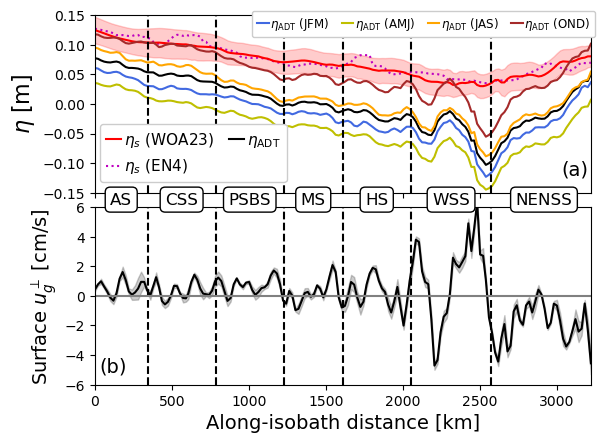

In [9]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)

ylo = etas_woa_annual.values - etas_woa_std.values
yhi = etas_woa_annual.values + etas_woa_std.values
ax1.fill_between(x, ylo, y2=yhi, color="r", alpha=0.2)

h11 = ax1.plot(x, adt_annual.values, "k-")
h12 = ax1.plot(x, etas_annual.values, "m:")
h13 = ax1.plot(x, etas_woa_annual.values, "r-")
l11, l12, l13 = r"$\eta_\text{ADT}$", r"$\eta_s$ (EN4)", r"$\eta_s$ (WOA23)"

cols = ["royalblue", "y", "orange", "brown"]
h21 = ax1.plot(x, adt.sel(season=ssns[0]).values, color=cols[0], alpha=1)
h22 = ax1.plot(x, adt.sel(season=ssns[1]).values, color=cols[1], alpha=1)
h23 = ax1.plot(x, adt.sel(season=ssns[2]).values, color=cols[2], alpha=1)
h24 = ax1.plot(x, adt.sel(season=ssns[3]).values, color=cols[3], alpha=1)
l21, l22, l23, l24 = [r"$\eta_\text{ADT}$ (JFM)", r"$\eta_\text{ADT}$ (AMJ)", r"$\eta_\text{ADT}$ (JAS)", r"$\eta_\text{ADT}$ (OND)"]

ax2.plot(x, ug0_annual.values, "k-", label=r"$u_g^\perp$ (ADT)")

ylo = ug0_annual.values - ug0_ssn_std.values
yhi = ug0_annual.values + ug0_ssn_std.values
ax2.fill_between(x, ylo, y2=yhi, color="k", alpha=0.2)

ax1.set_ylim(-0.15, 0.15)
ax2.set_ylim(-6, 6)
annotate_segments(ax2, ytxt=6.5)
_ = [ax1.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=2) for dd in dibound[1:-1]]
_ = [ax2.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=2) for dd in dibound[1:-1]]
ax1.set_xlim(0, x[-1])
ax1.tick_params(axis='both', direction='out'); ax2.tick_params(axis='both', direction='out')
ax2.axhline(color="gray")
leg1 = ax1.legend(handles=(h11[0], h12[0], h13[0]), labels=(l11, l12, l13), ncols=2, reverse=True, loc=(0.01, 0.06), framealpha=1, handlelength=1, handletextpad=0.15, columnspacing=1, fontsize=11)
ax1.add_artist(leg1)
leg2 = ax1.legend(handles=(h21[0], h22[0], h23[0], h24[0]), labels=(l21, l22, l23, l24), ncols=4, loc=(0.317, 0.875), framealpha=1, handlelength=1, handletextpad=0.15, columnspacing=1, fontsize=8.5)
ax2.set_xlabel(r"Along-isobath distance [km]", fontsize=14)
ax1.set_ylabel(r"$\eta$ [m]", fontsize=16)
ax2.set_ylabel(r"Surface $u_g^\perp$ [cm/s]", fontsize=14)
ax1.text(0.94, 0.13, "(a)", va="center", fontsize=14, transform=ax1.transAxes)
ax2.text(0.01, 0.1, "(b)", va="center", fontsize=14, transform=ax2.transAxes)
fig.subplots_adjust(hspace=0.08);

In [10]:
fig.savefig("fig3.png", bbox_inches="tight", dpi=200)